<a href="https://colab.research.google.com/github/rizkiismail9a/data-science-2026-unsia/blob/main/pertemuan_13_Muhamad_Rizki_Ismail_240401010126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Akurasi pada data uji: 0.900


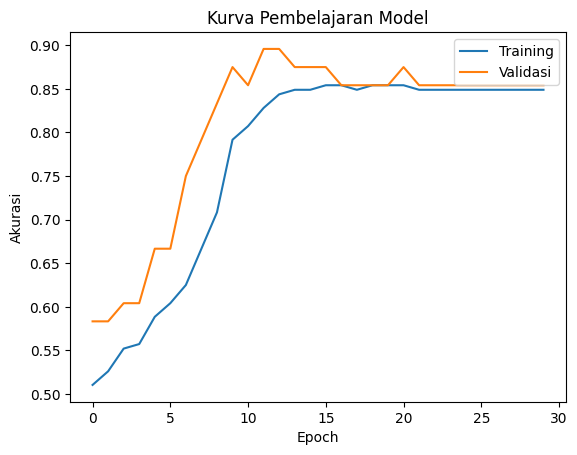

In [ ]:
# --------------
# Nama: Muhamad Rizki Ismail
# Kelas: IF401
# NIM: 240401010126
# --------------

# Pengantar Deep Learning

# Neural network sederhana
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_moons
# from sklearn.model_selection import train_test_split
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.layers import Input

# # Buat Dataset sederhana
# x, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# # Split Data
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# # Bangun arsitektur neural network
# model = Sequential(
#     [
#         Input(shape=(2,)), # Explicit Input Layer
#         Dense(16, activation="relu"), # No input_shape needed here now
#         Dense(8, activation="relu"),
#         Dense(1, activation="sigmoid"),
#     ]
# )

# # Latih model
# model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# history = model.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)

# # Evaluasi dan Viasualisasi
# loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
# print(f'Akurasi pada data uji: {accuracy:.3f}')


# plt.plot(history.history['accuracy'], label='Training')
# plt.plot(history.history['val_accuracy'], label='Validasi')
# plt.xlabel('Epoch'); plt.ylabel('Akurasi')
# plt.legend(); plt.title('Kurva Pembelajaran Model')
# plt.show()

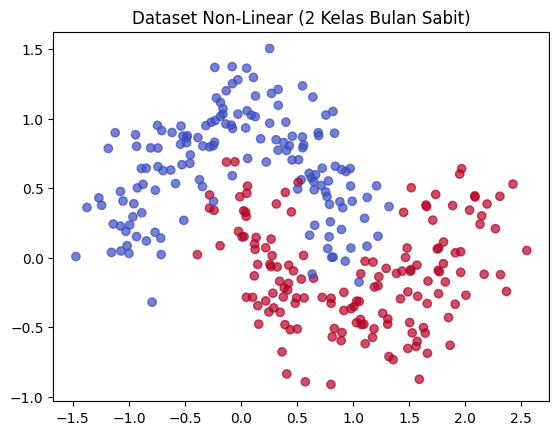

In [1]:
# Aktivitas Hands-On

# Buat dataset dummy non linear
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

x, y =  make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(x[:, 0], x[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("Dataset Non-Linear (2 Kelas Bulan Sabit)")
plt.show()

In [2]:
# Bangun dan Latih Neural Network Sederhana

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


# Split Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Bangun arsitektur neural network
model = Sequential(
    [
        Input(shape=(2,)), # Explicit Input Layer
        Dense(16, activation="relu"), # No input_shape needed here now
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.917


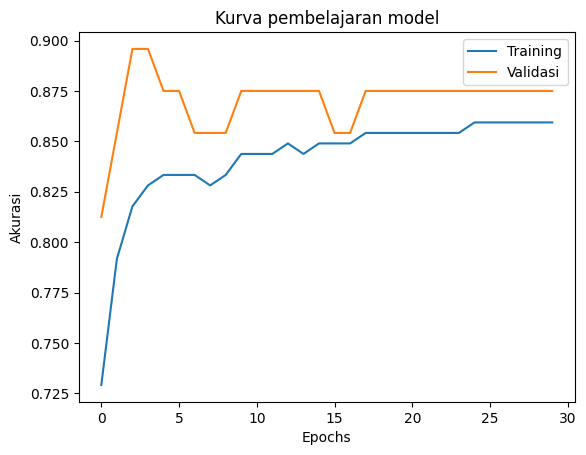

In [3]:
# Evaluasi dan Visualisasi

loss, acc = model.evaluate(x_test, y_test, verbose=0)

print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validasi")
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva pembelajaran model')
plt.show()

Akurasi data uji sebesar 0.917 berarti bahwa model neural network dapat mengklasifikasikan 91.7% dari total data uji dengan benar. Dengan kata lain, dari setiap 100 sampel data uji yang diberikan kepada model, sekitar 91 atau 92 sampel berhasil diprediksi kelasnya dengan tepat. Ini adalah metrik yang cukup baik, menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Berdasarkan kurva pembelajaran yang ditampilkan, akurasi training dan akurasi validasi cenderung mendekat seiring berjalannya epoch. Pada awalnya ada sedikit jarak, tetapi keduanya bergerak bersamaan dan berakhir cukup dekat satu sama lain, menunjukkan model belajar dengan baik tanpa overfit yang signifikan pada data training.

In [4]:
# Analisis Sentimen Sederhana

ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Respon penjual cepat dan ramah, mantap!',
    'Ukuran tidak pas, padahal sudah ikuti panduan',
    'Bahan tebal dan nyaman dipakai, suka sekali',
    'Warna tidak sesuai dengan yang ada di foto',
    'Proses pengemasan lama sekali, hampir seminggu',
    'Paking aman pakai bubble wrap tebal, barang mulus',
    'Fungsinya normal, tapi build quality agak ringkih',
    'Harga paling murah dibanding toko lain, kualitas oke',
    'Kapok belanja di sini, chat tidak pernah dibalas',
    'Desainnya elegan dan modern, pas banget di kamar',
    'Barang kurang satu item, tapi admin tanggung jawab kirim ulang',
    'Jahitannya kurang rapi, banyak benang yang lepas',
    'Sesuai pesanan, original, dan masih segel resmi',
    'Kurir langganan ramah, tapi barangnya cacat produksi',
    'Pengiriman instan cepat banget, hitungan jam sampai',
    'Aroma produknya aneh, tidak seperti yang biasa saya beli',
    'Berfungsi dengan baik, semoga awet dipakai harian',
    'Deskripsi bilang ready stock, tapi ternyata pre-order',
    'Dapat harga promo murah banget, worth it lah',
    'Baru dipakai dua hari langsung rusak, kecewa berat',
    'Seller komunikatif, dikasih tahu dulu kalau warna habis',
    'Materialnya terasa murah dan gampang tergores',
    'Pas banget di badan, instruksi pemakaian juga jelas',
    'Isinya bocor sedikit di dalam paket, untung tidak habis',
    'Barang sampai lebih cepat dari estimasi, terima kasih',
    'Tombol-tombolnya keras dan susah ditekan',
    'Sangat membantu untuk kebutuhan sehari-hari, praktis',
    'Spesifikasi di aplikasi berbeda dengan fisik aslinya',
    'Kombinasi warna bagus, sesuai dengan ekspektasi saya',
    'Agak kecewa karena ada bagian yang lecet sedikit',
    'Pelayanan purna jualnya oke, klaim garansi mudah',
    'Tidak ada petunjuk bahasa Indonesia, bingung pakainya',
    'Produk lokal tapi kualitasnya tidak kalah sama impor',
    'Aplikasi sering crash saat dihubungkan ke perangkat ini'
]

label = [
    1, 0, 1, 0, 1, 0,  # 6 label pertama
    1,  # Respon penjual cepat dan ramah, mantap!
    0,  # Ukuran tidak pas, padahal sudah ikuti panduan
    1,  # Bahan tebal dan nyaman dipakai, suka sekali
    0,  # Warna tidak sesuai dengan yang ada di foto
    0,  # Proses pengemasan lama sekali, hampir seminggu
    1,  # Paking aman pakai bubble wrap tebal, barang mulus
    1,  # Fungsinya normal, tapi build quality agak ringkih (cenderung positif karena fungsi normal)
    1,  # Harga paling murah dibanding toko lain, kualitas oke
    0,  # Kapok belanja di sini, chat tidak pernah dibalas
    1,  # Desainnya elegan dan modern, pas banget di kamar
    1,  # Barang kurang satu item, tapi admin tanggung jawab kirim ulang (positif karena tanggung jawab)
    0,  # Jahitannya kurang rapi, banyak benang yang lepas
    1,  # Sesuai pesanan, original, dan masih segel resmi
    0,  # Kurir langganan ramah, tapi barangnya cacat produksi
    1,  # Pengiriman instan cepat banget, hitungan jam sampai
    0,  # Aroma produknya aneh, tidak seperti yang biasa saya beli
    1,  # Berfungsi dengan baik, semoga awet dipakai harian
    0,  # Deskripsi bilang ready stock, tapi ternyata pre-order
    1,  # Dapat harga promo murah banget, worth it lah
    0,  # Baru dipakai dua hari langsung rusak, kecewa berat
    1,  # Seller komunikatif, dikasih tahu dulu kalau warna habis
    0,  # Materialnya terasa murah dan gampang tergores
    1,  # Pas banget di badan, instruksi pemakaian juga jelas
    0,  # Isinya bocor sedikit di dalam paket, untung tidak habis
    1,  # Barang sampai lebih cepat dari estimasi, terima kasih
    0,  # Tombol-tombolnya keras dan susah ditekan
    1,  # Sangat membantu untuk kebutuhan sehari-hari, praktis
    0,  # Spesifikasi di aplikasi berbeda dengan fisik aslinya
    1,  # Kombinasi warna bagus, sesuai dengan ekspektasi saya
    0,  # Agak kecewa karena ada bagian yang lecet sedikit
    1,  # Pelayanan purna jualnya oke, klaim garansi mudah
    0,  # Tidak ada petunjuk bahasa Indonesia, bingung pakainya
    1,  # Produk lokal tapi kualitasnya tidak kalah sama impor
    0   # Aplikasi sering crash saat dihubungkan ke perangkat ini
]

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfIdf = TfidfVectorizer()
x_text = tfIdf.fit_transform(ulasan)

print("Jumlah kata unik:", len(tfIdf.get_feature_names_out()))
print(tfIdf.get_feature_names_out()[:10])

Jumlah kata unik: 202
['ada' 'admin' 'agak' 'akan' 'aman' 'aneh' 'aplikasi' 'aroma' 'aslinya'
 'awet']


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

xt_tr, xt_te, yt_tr, yt_te = train_test_split(x_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(xt_tr, yt_tr)
akurasi = model_sentimen.score(xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Coba prediksi kalimat baru
kalimat_baru = ['Jelek ah']
pred = model_sentimen.predict(tfIdf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.500
Negatif


Mengapa hasil akurasi hanya 0.5?

Akurasi 0.5 pada model sentimen menunjukkan bahwa model tersebut hanya mampu memprediksi sentimen dengan benar sebanyak 50% dari waktu, yang setara dengan menebak secara acak untuk klasifikasi biner. Ada beberapa alasan mengapa akurasinya bisa begitu rendah:

  1. Ukuran Dataset yang Kecil: Anda hanya memiliki 40 ulasan. Untuk melatih model pembelajaran mesin yang dapat menggeneralisasi dengan baik, terutama untuk tugas yang kompleks seperti analisis sentimen, diperlukan jumlah data yang jauh lebih besar. Dengan data yang sedikit, model kesulitan menemukan pola yang signifikan dan robust.
  2. Keterbatasan Representasi Fitur (TF-IDF): Meskipun TF-IDF adalah teknik yang baik, dengan dataset sekecil ini dan tanpa preprocessing teks lebih lanjut (seperti menghapus stop words, stemming/lemmatisasi, atau mengubah ke huruf kecil), mungkin ada terlalu banyak kata unik yang muncul terlalu jarang, membuat representasi fitur kurang efektif.
  3. Keseimbangan Kelas (Class Imbalance): Jika jumlah ulasan positif dan negatif dalam dataset Anda sangat tidak seimbang, model mungkin cenderung bias ke kelas mayoritas, yang bisa menurunkan akurasi keseluruhan, terutama pada kelas minoritas.
  4. Kompleksitas Kalimat: Kalimat ulasan seringkali memiliki nuansa, sarkasme, atau penggunaan kata-kata yang kontekstual. Model linear seperti LogisticRegression mungkin kesulitan menangkap kompleksitas semantik ini.
  5. Ukuran Data Uji yang Sangat Kecil: Dengan test_size=0.2 dari 40 sampel, data uji Anda hanya terdiri dari 8 ulasan. Akurasi pada sampel yang sangat kecil ini bisa sangat fluktuatif dan tidak selalu mencerminkan kinerja model secara keseluruhan.
  6. Split Data yang Tidak Ideal: Dengan dataset kecil, pembagian data training dan testing bisa sangat mempengaruhi performa. Ada kemungkinan 8 sampel di data uji sangat sulit untuk diprediksi oleh model.
